# Bifurcaciones de tipo nodo - silla


Las bifurcaciones de nodo–silla son el mecanismo básico en el cual puntos de equilibrio son creados y destruidos.

Al variar el parámetro, los puntos de equilibrio se acercan (o se alejan)
de un punto, donde chocan y se aniquilan mutuamente.

La forma normal de esta bifurcacion es $ \dot x = r \pm x^2$ para $r\in \mathbb{R}$

Observemos que esta es una parabola que dependiendo de r, tendra 0, 1 o 2 puntos de equilibrio

como la existencia de dichas soluciones de equilibrio dependen de r, es decir, al valor de r donde solo existe una solucion lo llamaremos $r_{\text{critico}}$

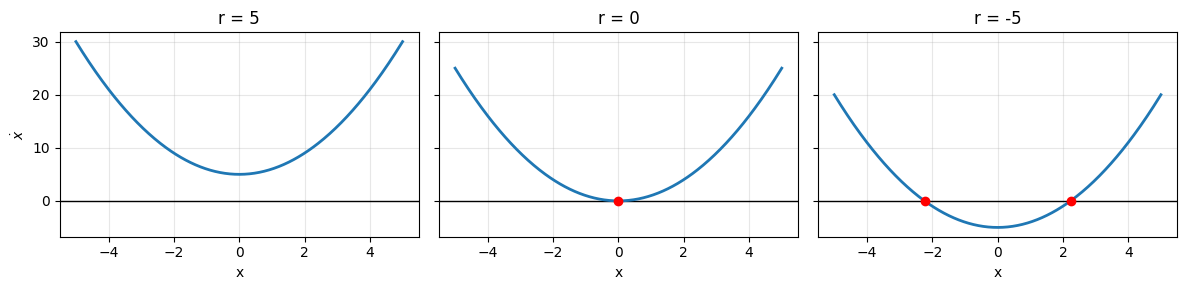

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rs = [5, 0, -5]
x = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, r in zip(axes, rs):
    f = r + x**2  # xdot = r + x^2

    ax.axhline(0, color="k", lw=1)
    ax.plot(x, f, lw=2)
    ax.set_title(f"r = {r}")
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

    # puntos de equilibrio: r + x^2 = 0  ->  x = ±sqrt(-r) si r<0
    if r < 0:
        xeq = np.array([-np.sqrt(-r), np.sqrt(-r)])
        ax.plot(xeq, np.zeros_like(xeq), "ro")
    elif r == 0:
        ax.plot([0], [0], "ro")

axes[0].set_ylabel(r"$\dot x$")
plt.tight_layout()
plt.show()


Esto nos dice que:

- para $r > 0$ no hay puntos de aquilibrio

-Para $r = 0$ tenemos solo un punto de equilibrio, que es $x^{*}=0$

-Para $r < 0$ tenemos 2 puntos de equilibrio, que son $x^{*} = \sqrt{r}$ y $x^{*} = -\sqrt{r}$

# Ejemplo

Consideremos el sistema $\dot x = r - x -e^{-x}$

Veamos que tiene una bifurcacion tipo nodo-silla en $r = 1$

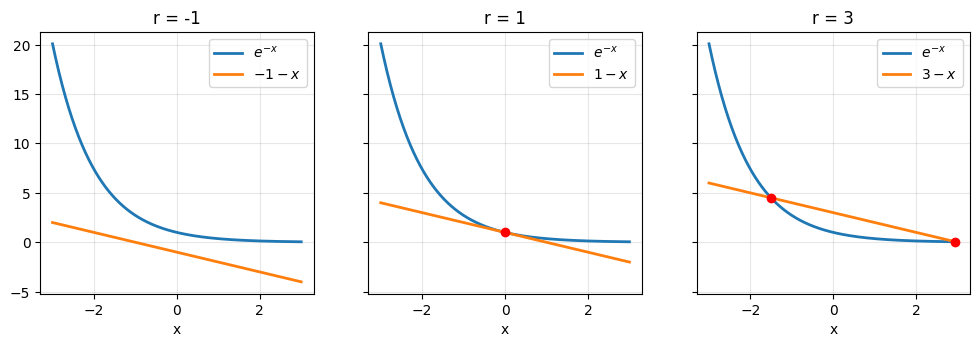

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def y_exp(x):
    return np.exp(-x)

def y_line(x, r):
    return r - x

# --- bisección para intersecciones exp(-x) = r - x ---
def bisect_root(fun, a, b, tol=1e-10, maxit=200):
    fa, fb = fun(a), fun(b)
    if fa == 0: return a
    if fb == 0: return b
    if fa * fb > 0:
        return None
    for _ in range(maxit):
        c = 0.5 * (a + b)
        fc = fun(c)
        if abs(fc) < tol or (b - a) < tol:
            return c
        if fa * fc <= 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return 0.5 * (a + b)

def find_intersections(r, xmin=-5, xmax=5, n=4000):
    x = np.linspace(xmin, xmax, n)
    g = y_exp(x) - y_line(x, r)  # = exp(-x) - (r-x)
    roots = []
    for i in range(n - 1):
        a, b = x[i], x[i+1]
        ga, gb = g[i], g[i+1]
        if ga == 0:
            roots.append(a)
        elif ga * gb < 0:
            root = bisect_root(lambda z: y_exp(z) - y_line(z, r), a, b)
            if root is not None:
                roots.append(root)

    # limpiar duplicados
    roots = sorted(roots)
    cleaned = []
    for rr in roots:
        if not cleaned or abs(rr - cleaned[-1]) > 1e-4:
            cleaned.append(rr)
    return cleaned

rs = [-1, 1, 3]
x = np.linspace(-3, 3, 600)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)

for ax, r in zip(axes, rs):
    ax.plot(x, y_exp(x), lw=2, label=r"$e^{-x}$")
    ax.plot(x, y_line(x, r), lw=2, label=rf"${r}-x$")

    inter = find_intersections(r, xmin=-5, xmax=5, n=4000)
    if inter:
        ax.plot(inter, y_exp(np.array(inter)), "ro", ms=6)

    # Forzar el punto de intersección para r=1 en x=0
    if r == 1:
        ax.plot([0], [1], "ro", ms=6)

    ax.set_title(f"r = {r}")
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
    ax.legend()


Esto nos muestra que: en $r = 1$ hay una bifurcacion tipo nodo-silla

O sea,

$$
\dot{x} = r - x - e^{-x}.
$$

Como

$$
e^{-x} = \sum_{n \in \mathbb{N}} (-1)^n \frac{x^n}{n!},
$$

así,

$$
\dot{x}=
r - x - e^{-x}
= r - x - \sum_{n \in \mathbb{N}} (-1)^n \frac{x^n}{n!}
= (r - 1) + \sum_{n \ge 2} (-1)^n \frac{x^n}{n!}
= (r - 1) + \frac{x^2}{2}
+ \sum_{n \ge 3} (-1)^n \frac{x^n}{n!}.
$$

Y el resto tiende a $0$, es decir:

$$\dot{x} = \frac{r-1}{2} + x^2$$
